In [3]:
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
# def free_energy():

N = 1000
np.random.seed(1917)

def form_M(β: (float | int), J : np.array) -> np.array:
    """form M matrix to analyze phase transition of spin glass

    Parameters
    ----------
    β  : (float | int)
        inverse temperature
    J : np.array
        bond matrix

    Returns
    -------
    np.array
        The M matrix allowing analysis of phase of phase transition

    """

    # check symmetric 
    assert np.allclose(J.T,J)

    #scale J by beta
    Jβ = J*β
    M = Jβ-β*np.diag( np.sum(Jβ**2, axis=1))
    return M 

In [5]:
# symmetrize
J = np.random.normal(0,1/(N)**(1/2),(N,N))
J = (J+J.T)/2
eigs = []
βs = [.1,.2,.3,.4,.5,.6,.7,.8,.9,1,1.2,1.4] 

for β in βs:
    M = form_M(β=β, J=J)
    eig_M = np.linalg.eig(np.eye(N)-M)
    eigs.append(min(eig_M.eigenvalues))

min_eigs = min(eigs)
min_β = βs[np.argmin(eigs)]

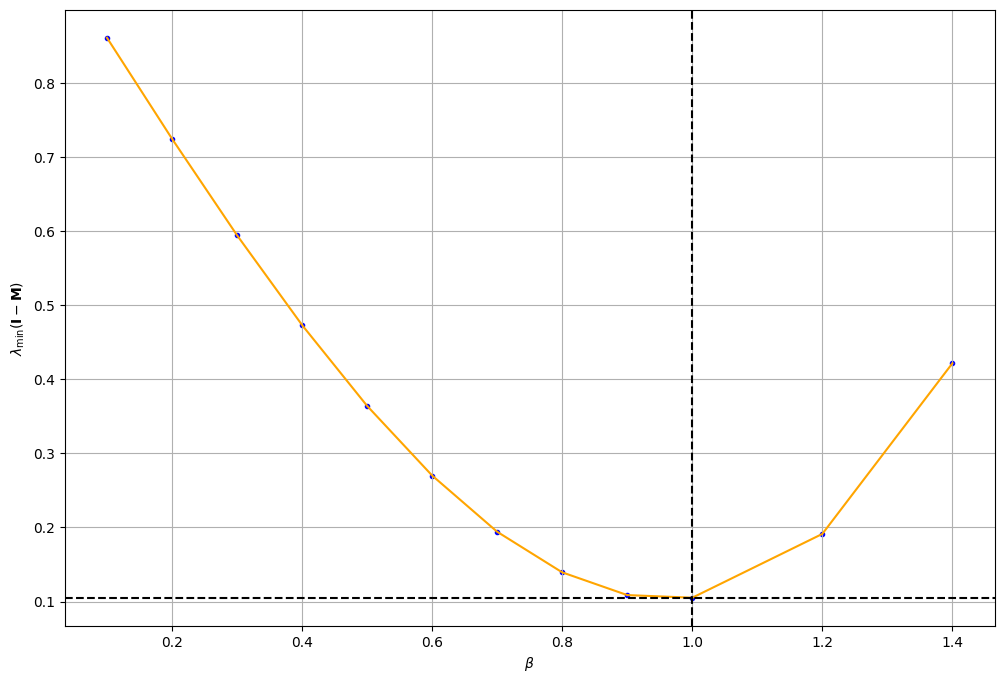

In [6]:
plt.figure(figsize=(12,8))
plt.plot(βs,eigs,color="orange")
plt.scatter(βs,eigs,color="blue", marker=".")
plt.title("")
plt.grid()
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\lambda_{\min} (\mathbf{I} - \mathbf{M})$")
plt.axhline(y=min_eigs, color="black", linestyle="--", label=f"Min λ = {min_eigs:.2f}")
plt.axvline(x=βs[np.argmin(eigs)], color="black", linestyle="--", label=f"At β = {min_β:.2f}")


In [ ]:
def calculate_spin_glass_free_energy(J, beta, tol=1e-6, max_iter=100):
    """
    Calculate the mean-field free energy for a spin-glass system.

    Parameters
    ----------
    J : np.ndarray
        Interaction matrix (NxN), where J[i, j] represents interaction strength between spins i and j.
    beta : float
        Inverse temperature (1 / (k_B * T)).
    tol : float, optional
        Convergence tolerance for magnetization and overlap updates.
    max_iter : int, optional
        Maximum number of iterations for convergence.

    Returns
    -------
    f_MF : float
        Mean-field free energy per site.
    """
    N = J.shape[0]
    
    # Initialize magnetizations and overlap
    m = np.zeros(N)
    q = 0.0

    for _ in range(max_iter):
        m_prev = m.copy()

        # Update magnetizations
        h_eff = np.sum(β * np.dot(J.T, mj) - β**2*J.T**2@(1-mj**2)*m)
        m[i] = np.tanh(h_eff)

        # Update overlap
        q = np.mean(m**2)

        # Check for convergence
        if np.max(np.abs(m - m_prev)) < tol and np.abs(q - q_prev) < tol:
            break

    # Calculate free energy
    term1 = -0.5 * np.sum(J * np.outer(m, m))
    term2 = -0.25 * beta * np.sum(J**2) * (1 - q)**2
    term3 = (1 / N) * np.sum(np.log(2 * np.cosh(beta * h_eff)))
    f_MF = (term1 + term2 + term3) / N

    return f_MF

# Example usage
N = 10  # Number of spins
beta = 1.0
J = np.random.normal(0, 1 / np.sqrt(N), size=(N, N))  # Interaction matrix
J = (J + J.T) / 2  # Symmetrize for pairwise interactions

f_MF = calculate_spin_glass_free_energy(J, beta)
print(f"Mean-Field Free Energy per site: {f_MF}")

Mean-Field Free Energy per site: -0.053399961683366005


In [13]:
n=20*2
δt = .7/(n)**2
βc = .7
βs = [ βc*(1-i*δt) for i in range(0,n+1)]
βs

[0.7,
 0.69969375,
 0.6993874999999999,
 0.6990812499999999,
 0.6987749999999999,
 0.69846875,
 0.6981625,
 0.69785625,
 0.69755,
 0.6972437499999999,
 0.6969375,
 0.6966312499999999,
 0.696325,
 0.69601875,
 0.6957125,
 0.6954062499999999,
 0.6950999999999999,
 0.69479375,
 0.6944875,
 0.69418125,
 0.6938749999999999,
 0.69356875,
 0.6932625,
 0.6929562499999999,
 0.69265,
 0.6923437499999999,
 0.6920375,
 0.6917312499999999,
 0.691425,
 0.69111875,
 0.6908124999999999,
 0.69050625,
 0.6901999999999999,
 0.68989375,
 0.6895875,
 0.68928125,
 0.6889749999999999,
 0.6886687499999999,
 0.6883625,
 0.6880562499999999,
 0.68775]

In [14]:
2**16

65536